<a href="https://colab.research.google.com/github/66stella99/datasciencecoursera/blob/master/python_lib_exam_stella.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
#upload files
from google.colab import files
data_ = files.upload()
df_orders = pd.read_csv('orders (1).csv')
data_ = files.upload()
df_customers = pd.read_csv('customers (1).csv')
data_ = files.upload()
df_items = pd.read_csv('Items (1).csv')
data_ = files.upload()
df_order_item = pd.read_csv('order_item (1).csv')

Saving orders (1).csv to orders (1) (6).csv


Saving customers (1).csv to customers (1) (3).csv


Saving Items (1).csv to Items (1) (2).csv


Saving order_item (1).csv to order_item (1) (1).csv


In [38]:
#copy dataframes
df_orders_copy = df_orders.copy()
df_customers_copy = df_customers.copy()
df_items_copy = df_items.copy()
df_order_item_copy = df_order_item.copy()

In [39]:
#Handle duplicate data
#check missing data in %
df_items_copy.isnull().sum()*100/len(df_items_copy)

,0
id,0.0
item_name,0.0
item_category,16.0
item_price,0.0
stock_quantity,10.0
item_brand,6.0
item_availability,0.0


In [40]:
#Handle duplicate data
# Data Preparation: a.i. check if item name and same item brand.
df_items_copy[df_items_copy.duplicated(['item_name','item_brand'])]
# Data Preparation: a.ii. check items with missing brand
df_items_copy[df_items_copy['item_brand'].isnull()]



,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability
7,8,Headphone,NaN,3117.19,599.0,NaN,True
9,10,DVD Player,Video Players and Recorders,453.85,605.0,NaN,True
36,37,Antivirus Software,Software,4186.62,NaN,NaN,False


In [41]:
df_items_copy[df_items_copy['item_name']=='Headphone']
#Data Preparation: a.ii. remove id 8 line 7 from item
df_items_copy.drop(7, inplace=True)


In [132]:
#update missing data in %
df_items_copy.isnull().sum()*100/len(df_items_copy)

,0
id,0.0
item_name,0.0
item_category,0.0
item_price,0.0
stock_quantity,0.0
item_brand,0.0
item_availability,0.0


In [126]:
#drop  item_brand below 5%
df_items_copy.dropna(subset=['item_brand'],inplace=True)

In [129]:
#fill item_category with unkown
df_items_copy['item_category'].fillna('unknown',inplace=True)

/tmp/ipykernel_27855/1645412141.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_items_copy['item_category'].fillna('unknown',inplace=True)


In [131]:
#fill stock value with 0
df_items_copy['stock_quantity'].fillna(0,inplace=True)


/tmp/ipykernel_27855/577294592.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_items_copy['stock_quantity'].fillna(0,inplace=True)


In [51]:
#check missing data for order_item
df_order_item_copy.isnull().sum()*100/len(df_order_item_copy)


,0
Unnamed: 0,0.0
id,0.0
order_id,0.0
item_id,4.0
quantity,0.0


In [58]:
#Data Preparation: 3.b. drop missing data for item_id
df_order_item_copy.dropna(subset=['item_id'], inplace=True)

In [59]:
#check if fixed
df_order_item_copy.isnull().sum()*100/len(df_order_item_copy)


,0
Unnamed: 0,0.0
id,0.0
order_id,0.0
item_id,0.0
quantity,0.0


In [62]:
#fix item_id to integer
df_order_item_copy['item_id'] = df_order_item_copy['item_id'].astype(int)

In [70]:
# Data Preparation: 1.b find and remove oreders with  item id=8
df_order_item_copy_drop = df_order_item_copy.loc[df_order_item_copy['item_id']==8]
df_order_item_copy=df_order_item_copy.drop(df_order_item_copy_drop.index)

In [72]:
df_order_item_copy

,Unnamed: 0,id,order_id,item_id,quantity
0,0,1,337,10,2
1,1,2,430,27,6
2,2,3,430,36,2
3,3,4,508,46,1
4,4,5,229,27,2
...,...,...,...,...,...
995,995,996,594,24,2
996,996,997,330,32,8
997,997,998,472,10,3
998,998,999,222,29,1


In [76]:
#Data Preparation: 2.a handle duplicate data in customer
df_customers_copy[df_customers_copy.duplicated(subset=['email'])]

,id,first_name,last_name,gender,age,nationallity,joining_date,phone_number,email


In [94]:
#Data Preparation: 3.a find and fill missing data in costumer
df_customers_copy.isnull().sum()*100/len(df_customers_copy)


,0
id,0.0
first_name,0.0
last_name,0.0
gender,0.0
age,0.0
nationallity,0.0
joining_date,0.0
phone_number,0.0
email,0.0


In [81]:
#check most common  gender
df_customers_copy['gender'].value_counts()
#Data Preparation: 3.a fill as female
df_customers_copy['gender'].fillna('Female',inplace=True)

/tmp/ipykernel_27855/4004421549.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_customers_copy['gender'].fillna('Female',inplace=True)


In [88]:
#convert to np datetime
df_customers_copy['joining_date'] = pd.to_datetime(df_customers_copy['joining_date'])
# Data Preparation: 3.a. fill missing date with 1-1-2022
df_customers_copy['joining_date'] = df_customers_copy['joining_date'].fillna(pd.Timestamp('2022-01-01'))

In [93]:
#Data Preparation: 3.a fill missing age with average
df_customers_copy['age'].fillna(df_customers_copy['age'].mean(),inplace=True)

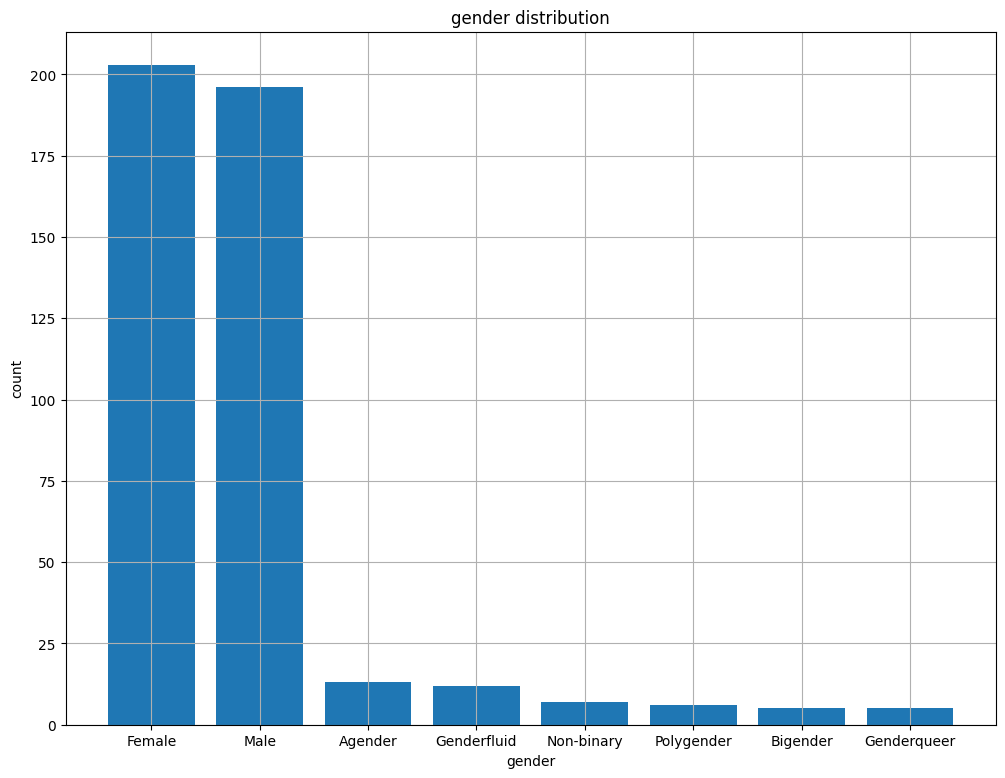

In [106]:
# Data analysis: 1.a number of customers for each gender
plt.figure(figsize = (12,9))
gender_count = df_customers['gender'].value_counts()
plt.bar(gender_count.index,gender_count)
plt.title('gender distribution')
plt.xlabel('gender')
plt.ylabel('count')
plt.grid()
plt.show()


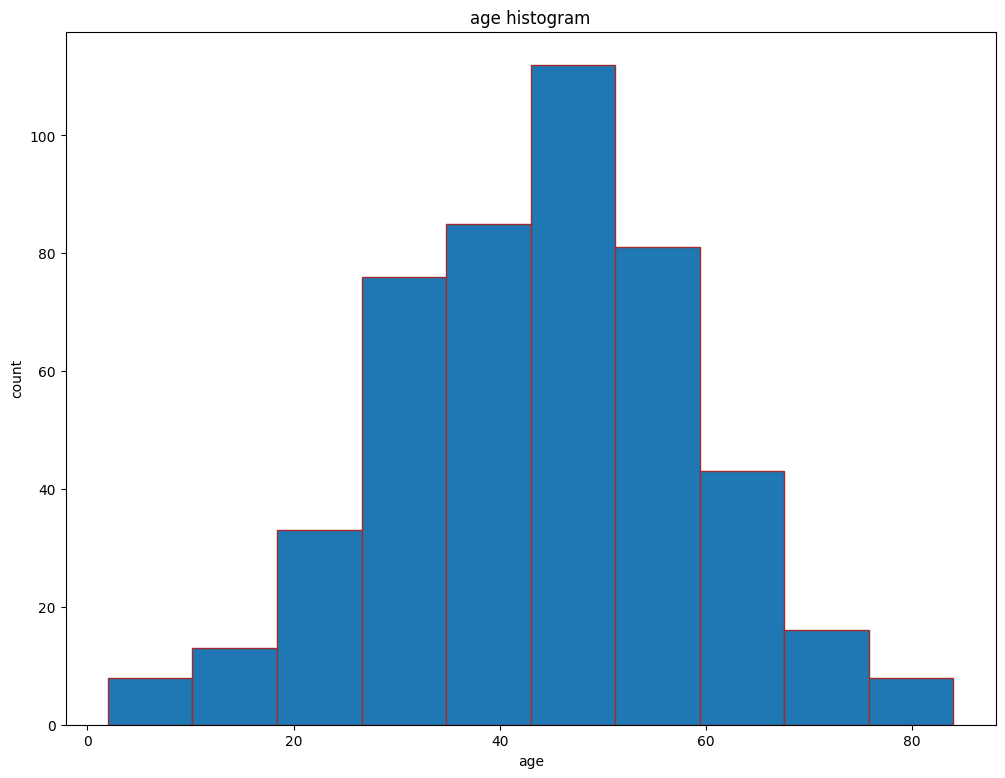

In [113]:
#Data analysis: 1.b age distribution
plt.figure(figsize = (12,9))
plt.hist(df_customers['age'],edgecolor='brown')
plt.title('age histogram')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

In [ ]:
#Data analysis: 1.c year with most joining customers
df_customers_copy.resample(rule='y')

In [133]:
df_items_copy

,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability
0,1,Television,Televisions and Displays,356.81,1009.0,JBL,True
1,2,Laptop,Computers and Accessories,1851.32,493.0,HP,True
2,3,Desktop,Computers and Accessories,1121.84,334.0,HP,True
3,4,Smartphone,Mobile Devices and Accessories,965.20,201.0,Bose,True
4,5,Tablet,unknown,2739.61,190.0,Toshiba,True
5,6,Printer,Printers and Office Equipment,4175.99,971.0,Sony,True
6,7,Camera,Photography Equipment,2366.72,458.0,Microsoft,True
8,9,Speaker,Audio Equipment,4471.27,1360.0,Toshiba,True
10,11,Blu-Ray Player,Video Players and Recorders,3382.86,704.0,ASUS,True
11,12,Video Game Console,Gaming Equipment,689.61,753.0,Microsoft,True


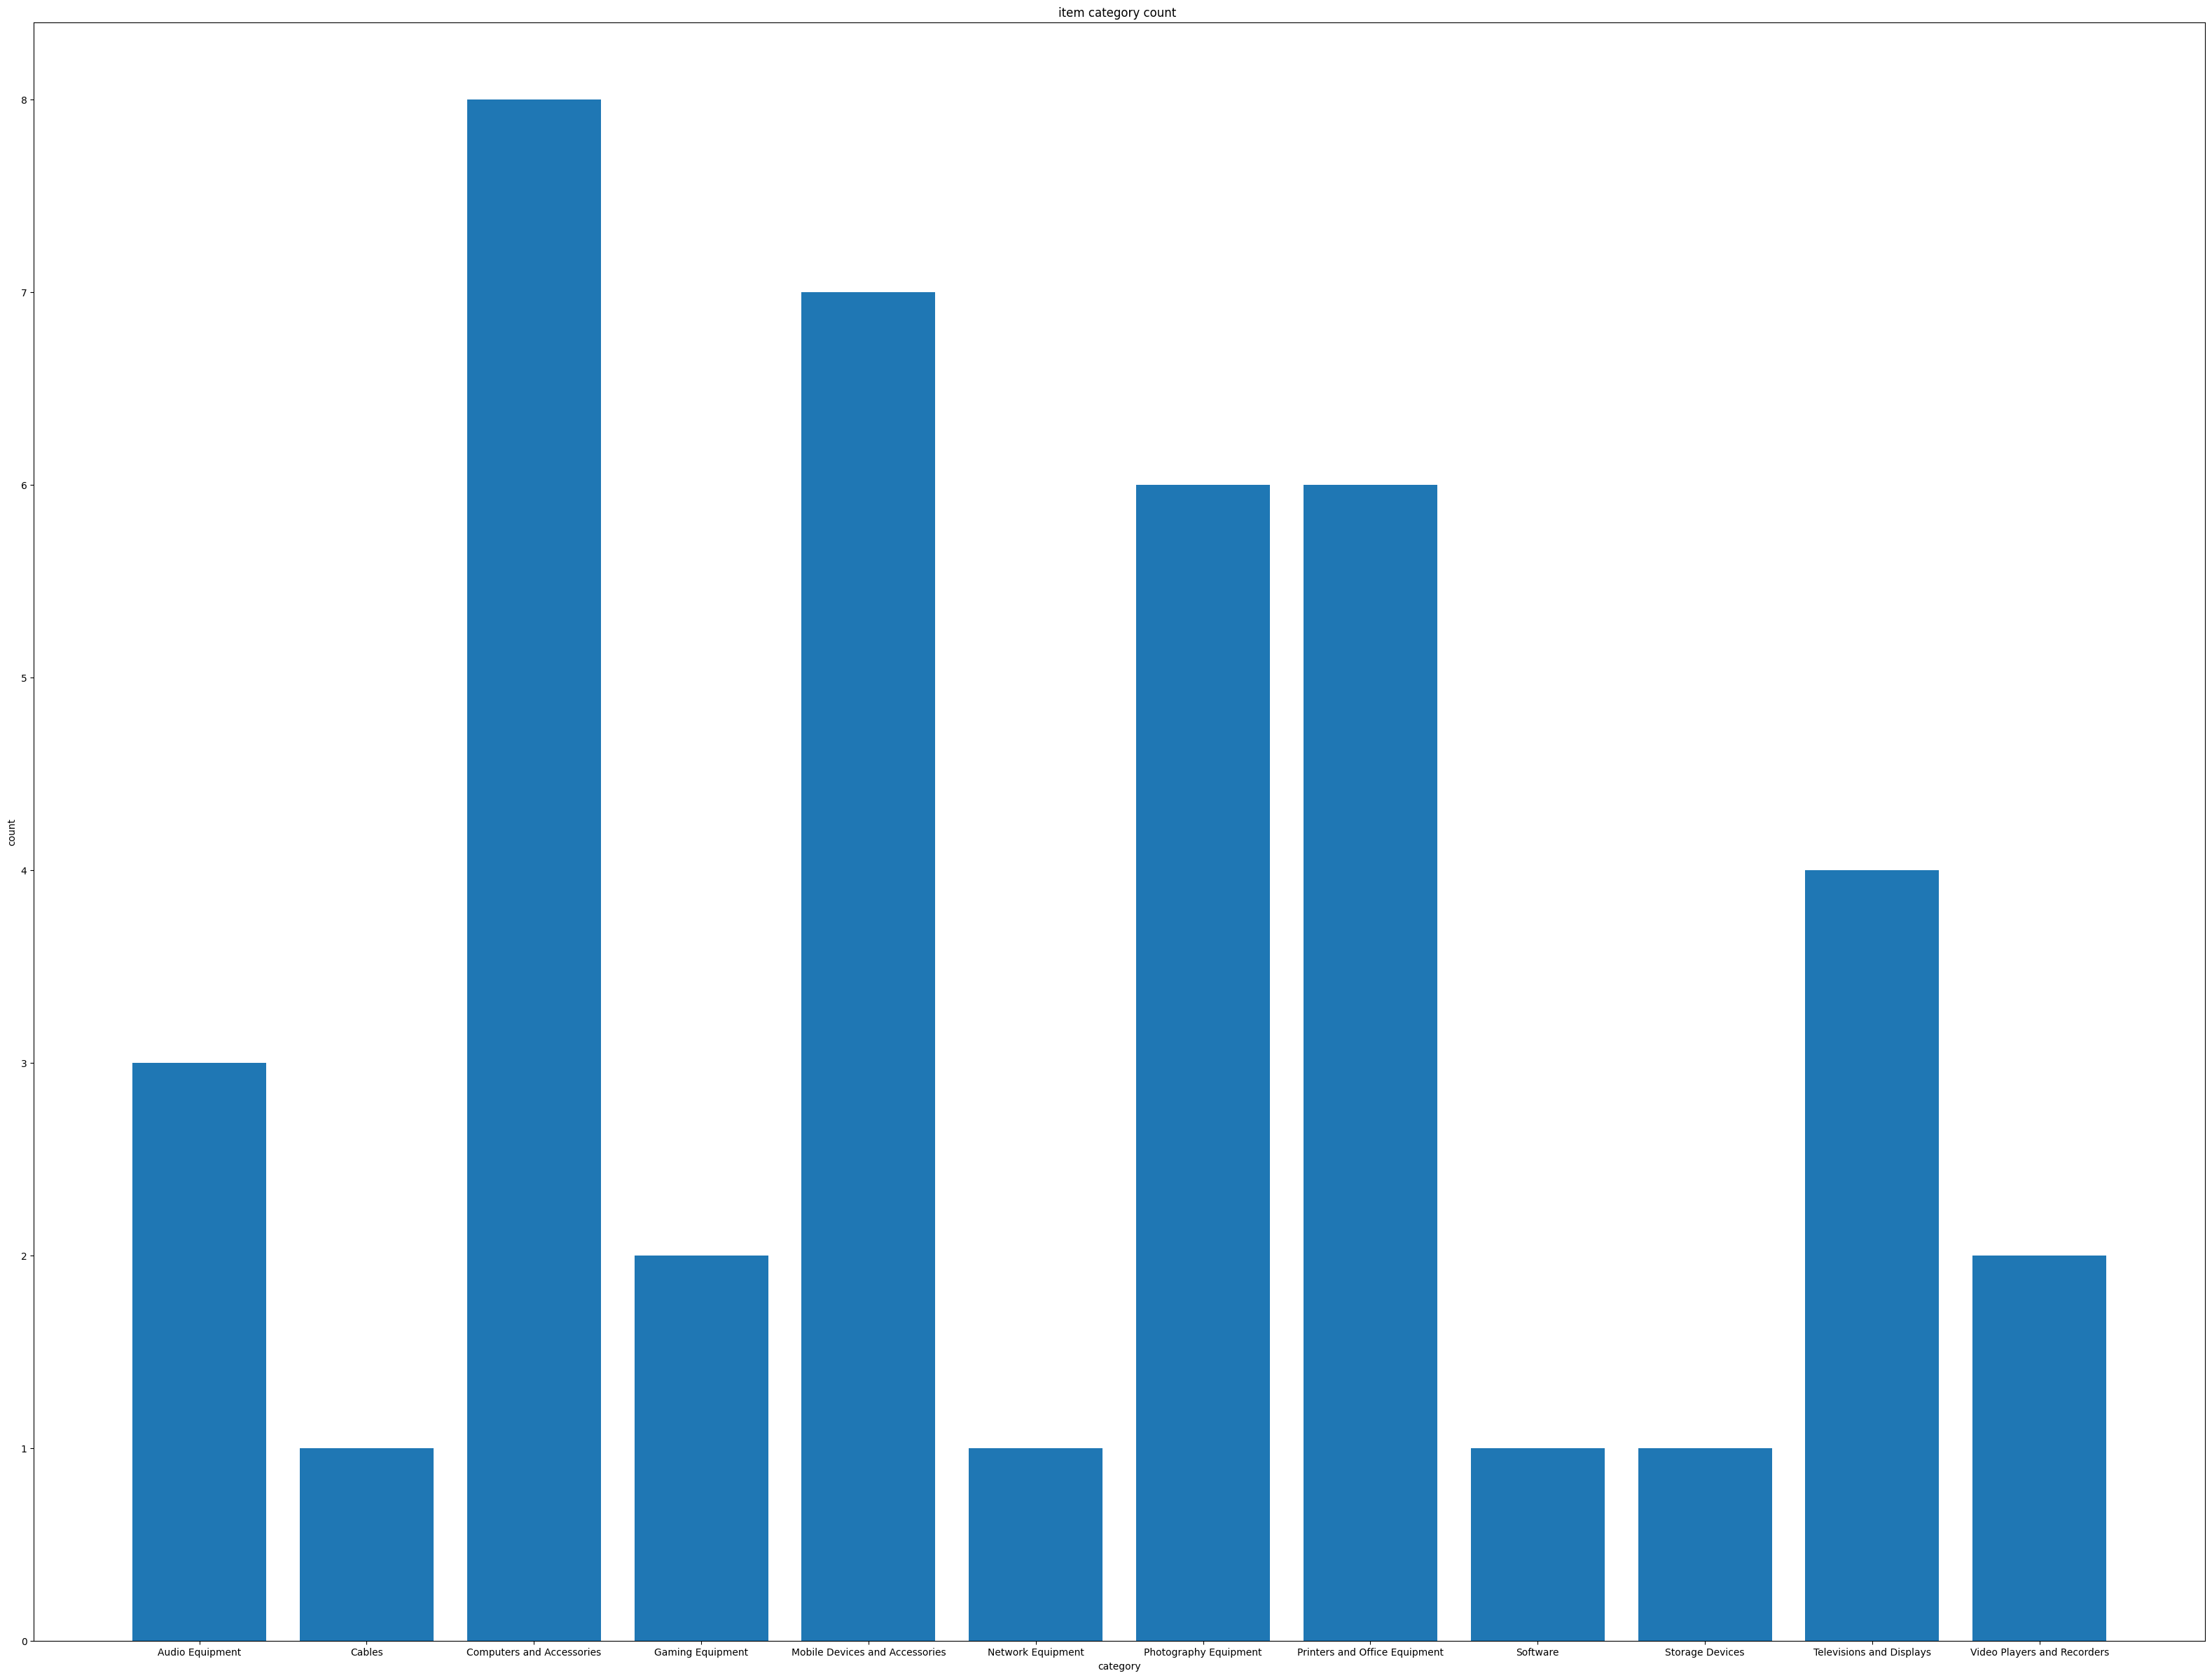

In [176]:
#Data analysis: 2.a Count the number of items by category
items_per_category = df_items.groupby('item_category')['id'].count()
plt.figure(figsize=(40,30))
plt.bar(items_per_category.index,items_per_category.values)
plt.title('item category count ')
plt.xlabel('category')
plt.ylabel('count')
plt.show()

In [165]:
#2.b hightst and lowest in stock
df_item_high_low = df_items.sort_values('stock_quantity')
df_item_high_low = df_item_high_low[df_item_high_low['stock_quantity']>0]
df_item_high_low= pd.concat([df_item_high_low.head(1),df_item_high_low.tail(1)])

In [169]:
#2.c average quanity in stock
round(df_items['stock_quantity'].mean())

743

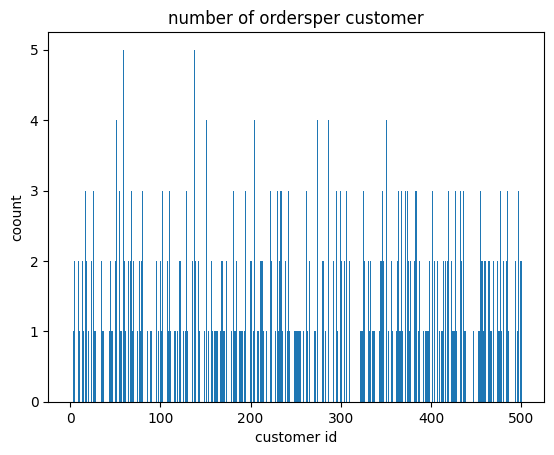

In [177]:
#3.a Calculate the amount of customers
order_group = df_orders_copy.groupby('customer_id')['order_id'].count()
plt.bar(order_group.index,order_group.values)
plt.title('number of orders per customer')
plt.xlabel('customer id')
plt.ylabel('coount')
plt.show()

In [183]:
#3.b top 5 customers
customer_group = df_orders_copy.merge(df_customers_copy,left_on='customer_id',left_index='id',how='inner')

ValueError: left_index parameter must be of type bool, not <class 'str'>

In [185]:
#4.a total price of each order.
df_orders_copy

,order_id,customer_id,delivery_address,delivery_days,order_date,payment_method,order_source
0,1,477.0,576 Cordelia Place,2.0,2023-12-05,GIFT_CARD,WEBSITE
1,2,93.0,4664 6th Drive,4.0,2023-08-17,CASH,STORE
2,3,474.0,8766 4th Point,4.0,2023-02-25,CHECK,STORE
3,4,333.0,31 Bonner Way,3.0,2023-02-04,CASH,STORE
4,5,436.0,20352 Shelley Way,5.0,2023-06-01,CASH,STORE
...,...,...,...,...,...,...,...
595,596,110.0,26 Hudson Lane,5.0,2023-10-30,CREDIT_CARD,WEBSITE
596,597,209.0,37392 Sullivan Park,4.0,2023-08-23,CREDIT_CARD,WEBSITE
597,598,480.0,1473 Ilene Drive,4.0,2023-09-11,CASH,STORE
598,599,72.0,2 Nancy Crossing,4.0,2023-02-09,CASH,STORE


In [187]:
#4.c correlation between the number of items in order and the delivery time
merge_order_items = df_order_item_copy.merge(df_orders_copy,left_on='order_id',right_on='order_id')


,Unnamed: 0,id,order_id,item_id,quantity,customer_id,delivery_address,delivery_days,order_date,payment_method,order_source
0,0,1,337,10,2,26.0,944 Weeping Birch Pass,6.0,2023-12-06,CASH,STORE
1,1,2,430,27,6,56.0,1350 Memorial Alley,NaN,2023-07-02,CHECK,STORE
2,2,3,430,36,2,56.0,1350 Memorial Alley,NaN,2023-07-02,CHECK,STORE
3,3,4,508,46,1,356.0,457 Ruskin Drive,4.0,2023-05-11,CREDIT_CARD,WEBSITE
4,4,5,229,27,2,394.0,8 Rutledge Park,4.0,2023-07-30,GIFT_CARD,WEBSITE
...,...,...,...,...,...,...,...,...,...,...,...
936,995,996,594,24,2,480.0,242 Brown Avenue,6.0,2023-02-18,GIFT_CARD,STORE
937,996,997,330,32,8,191.0,5862 Old Shore Parkway,5.0,2023-04-04,CREDIT_CARD,STORE
938,997,998,472,10,3,129.0,4 Arkansas Drive,3.0,2023-02-27,CREDIT_CARD,WEBSITE
939,998,999,222,29,1,NaN,9083 Toban Road,5.0,2023-04-25,CHECK,WEBSITE
